In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from zlib import crc32
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array ,check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.model_selection import cross_val_score

df = pd.read_csv("spam.csv",encoding="latin-1")

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None 
 v1
ham     4825
spam     747
Name: count, dtype: int64


 2002    TheMob>Yo yo yo-Here comes a new selection of ...
730     Email AlertFrom: Jeri StewartSize: 2KBSubject:...
3494    Wan2 win a Meet+Greet with Westlife 4 U or a m...
1049    18 days to Euro2004 kickoff! U will be kept in...
2710    Hope you enjoyed your new content. text stop t...
4010    Please call our customer service representativ...
649     You have won ?1,000 cash or a ?2,000 prize! To...
374     Thanks for your Ringtone Order, Reference T91....
1686    todays vodafone numbers ending with 0089(my la...
2296    <Forwarded from 21870000>Hi - this is your Mai...
Name: v2, dtype: str


<Axes: xlabel='v1', ylabel='Count'>

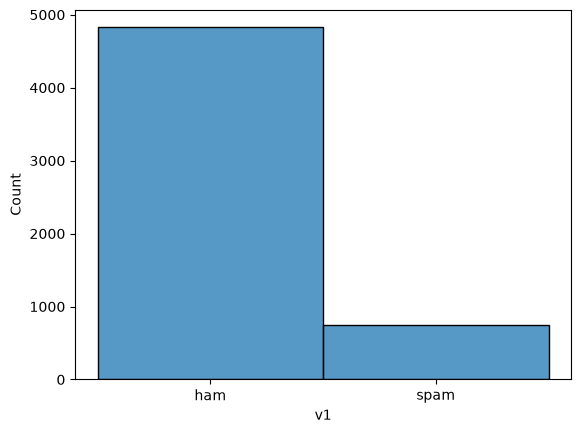

In [3]:
print(df.info(),"\n",df["v1"].value_counts())
print("\n\n",df["v2"][df["v1"] == "spam"].sample(10))
sns.histplot(data=df,x="v1")

In [4]:
print("Duplicated : ",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("\nDuplicated : ",df.duplicated().sum())

Duplicated :  403

Duplicated :  0


In [5]:
rename_mapping = {
    "v1" : "label",
    "v2" : "text"
}
df.rename(columns = rename_mapping,inplace=True)
print(df.columns)

Index(['label', 'text'], dtype='str')


# The dataset doesn't have any direct mathematical or even categorical proportions. So we do :
# Text Procceing

In [6]:
X = df[["text"]]
y = df["label"]
X_train , X_test, y_train , y_test = train_test_split(X,y,random_state=25,stratify=y)